# Lab 2 

## Task 1
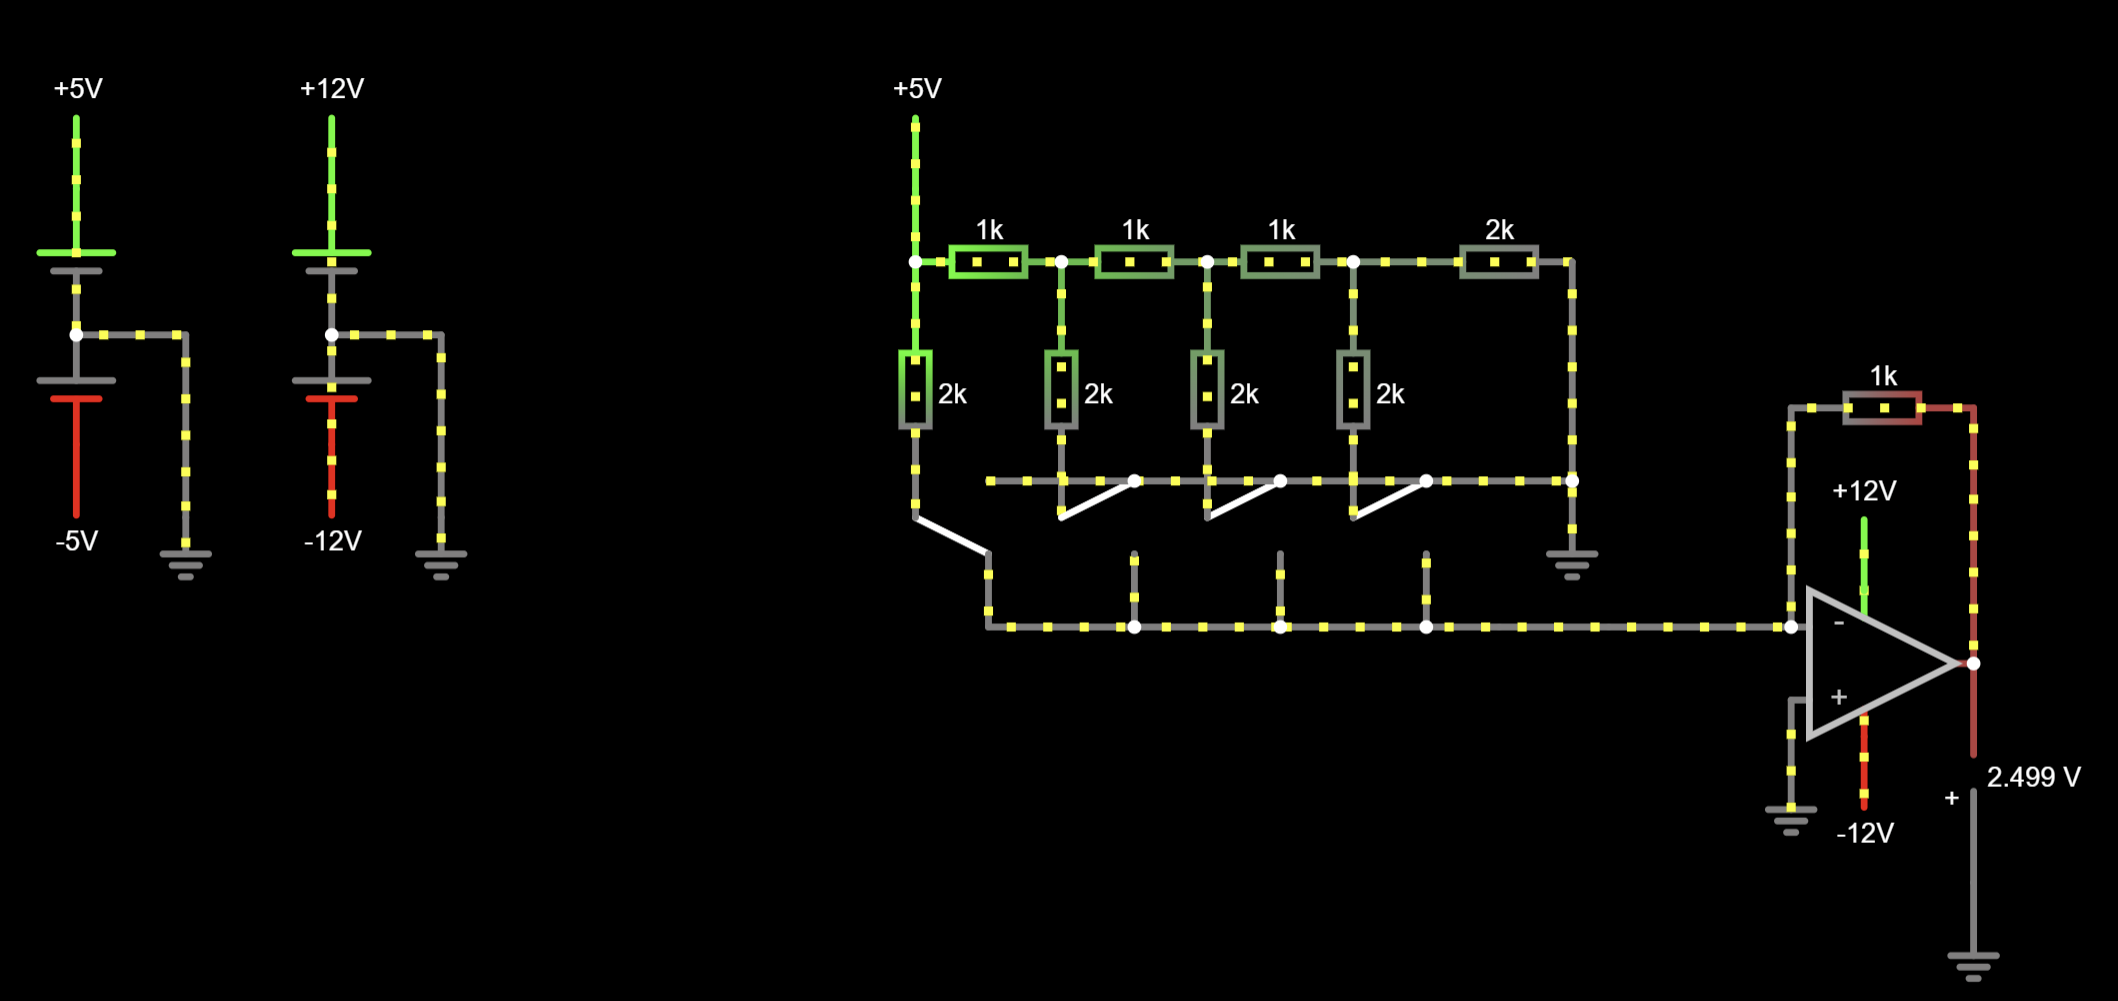

Most significant is the leftmost on the schema.

| Code (DEC)    | 0     | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 | 12 | 13 | 14 | 15 |
| :--- | :---   | :---  | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :---     | :---  | :--- | :--- |
| Code (BIN)    |0000|0001|0010|0011|0100|0101|0110|0111|1000|1001|1010|1011|1100|1101|1110| 1111 |
| U_out [mV]    |-0.5|311 |624 |937 |1250|1560|1870|2180|2500|2810|3120|3440|3750|4060|4370|4690|

Q: What is the role of the opamp in the examined R-R2 ladder circuit?
    
    The purpose is to turn current into voltage

Q: What is the difference between two schema?
    
    First is current based, second one is voltage based.

Alternative 

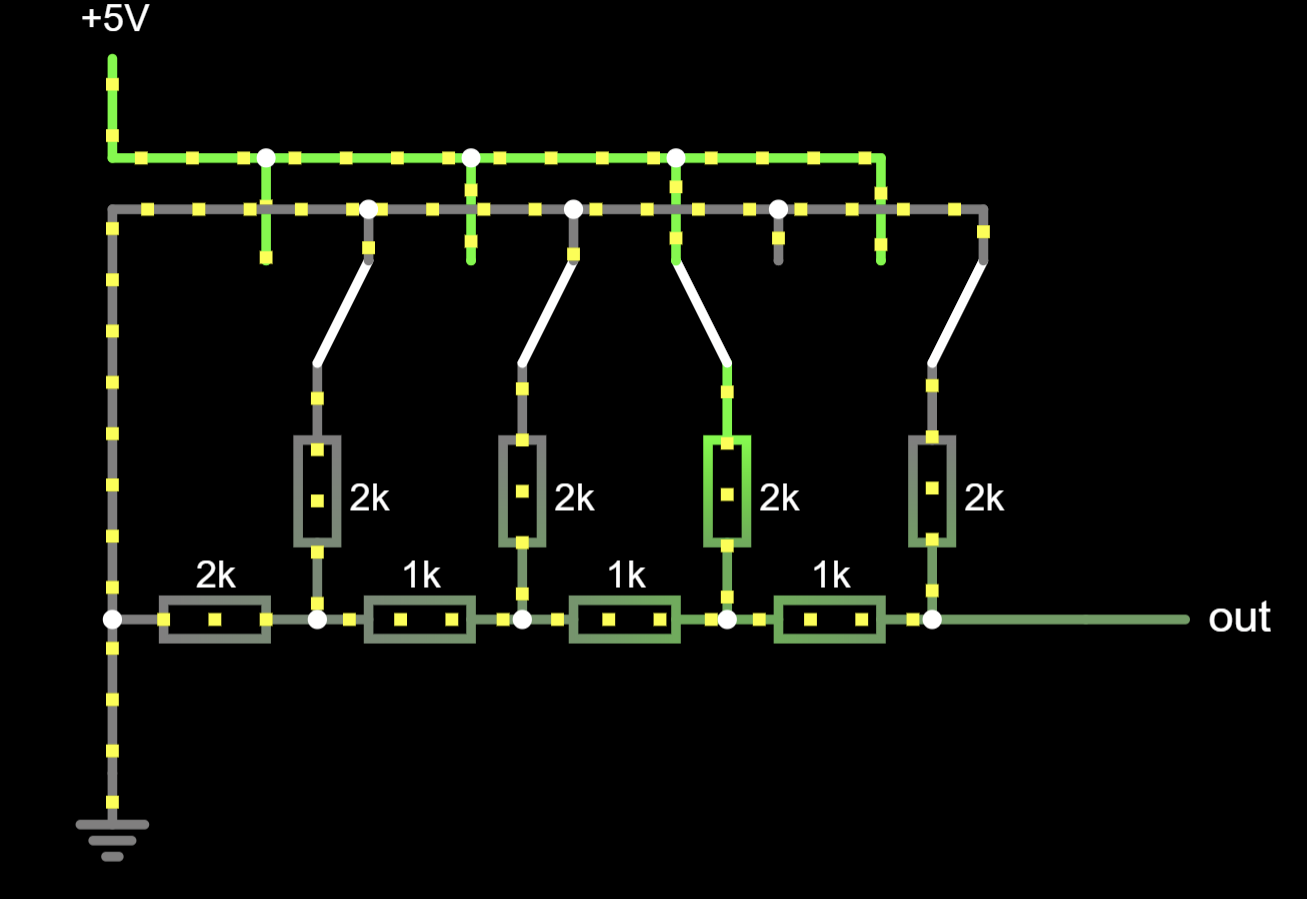


## Task 2

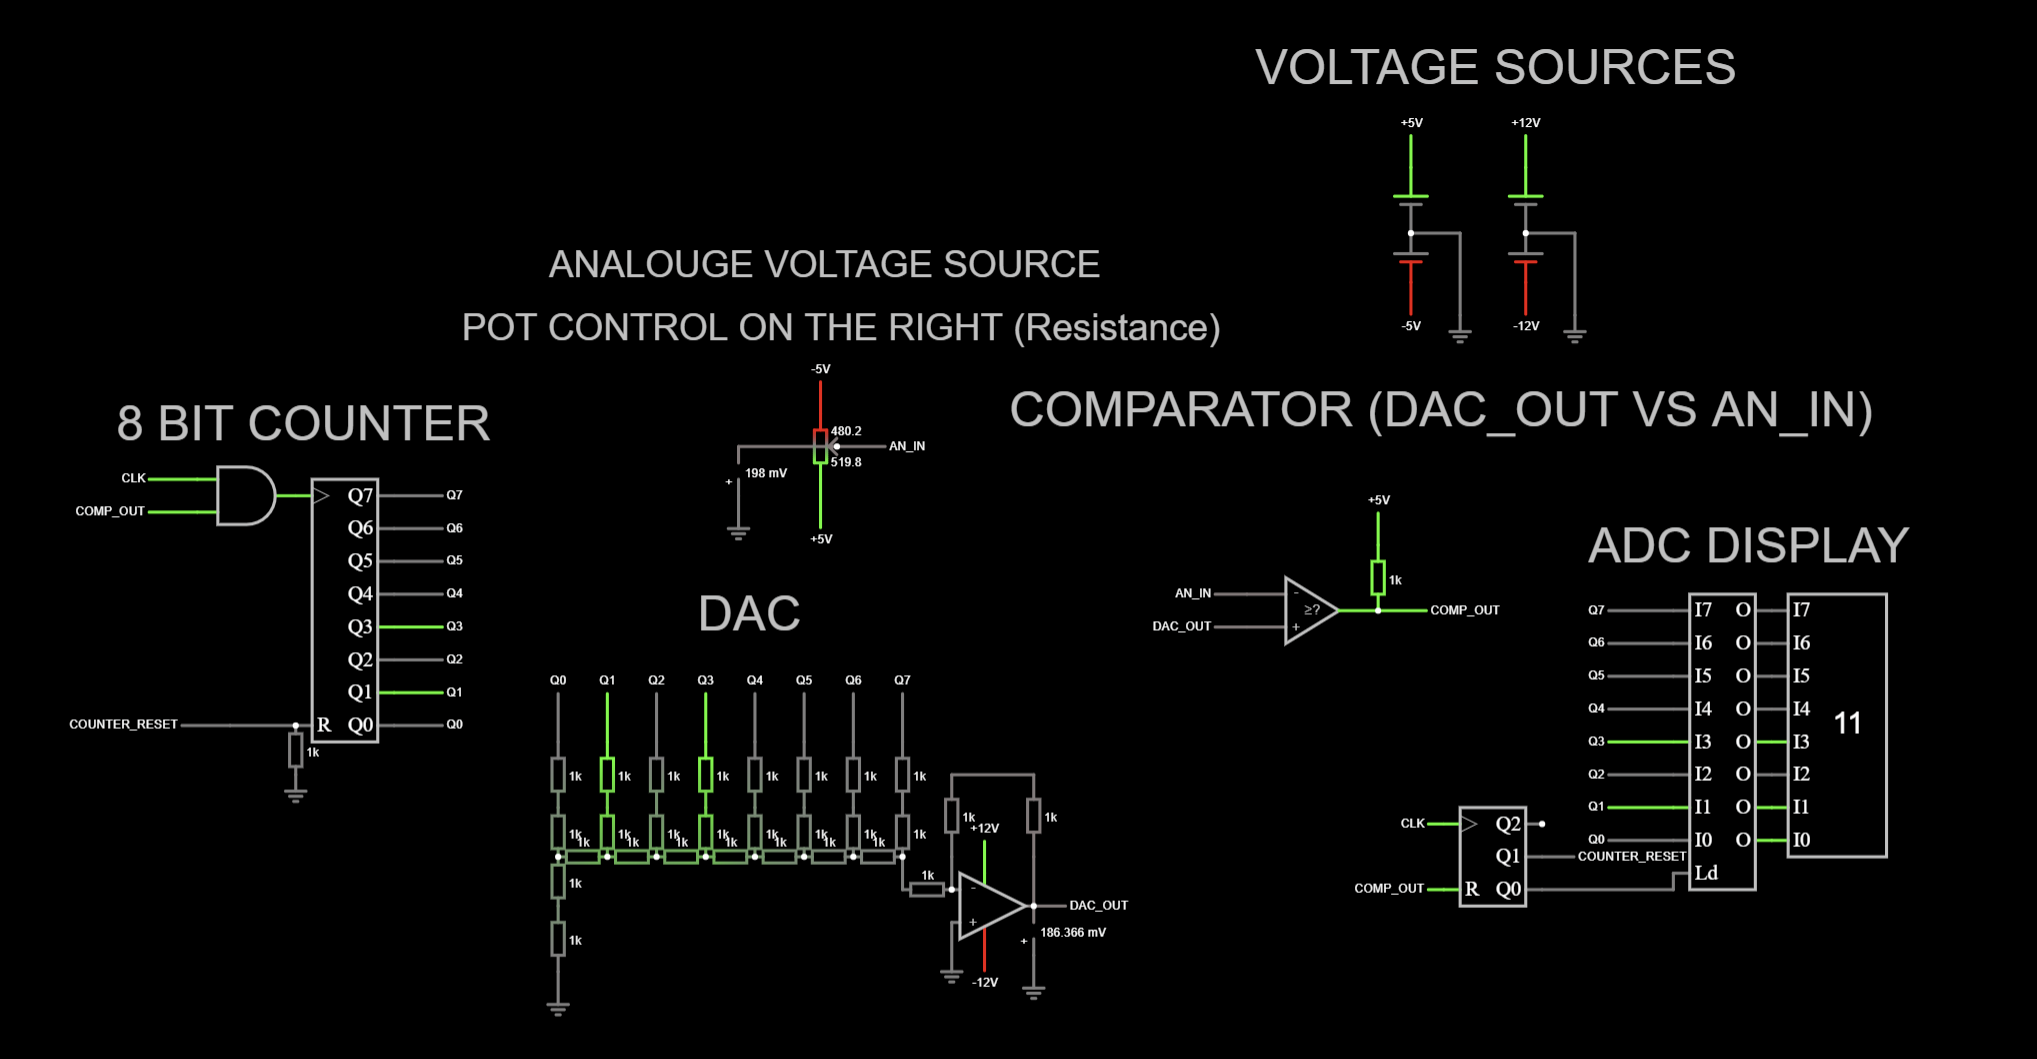

This is ADC. There is a input voltage generator with potentiometer. (Analog Voltage source) This voltage is sent into a comparator, which creates a reset pulse.

The 8 bit counter counts up until the reset pulse. The DAC outputs a voltage according to the binary counter and sends it into the comparator. 

The binary number is also sent into the display cirquit. It outputs the number into display when it gets a pulse to Ld

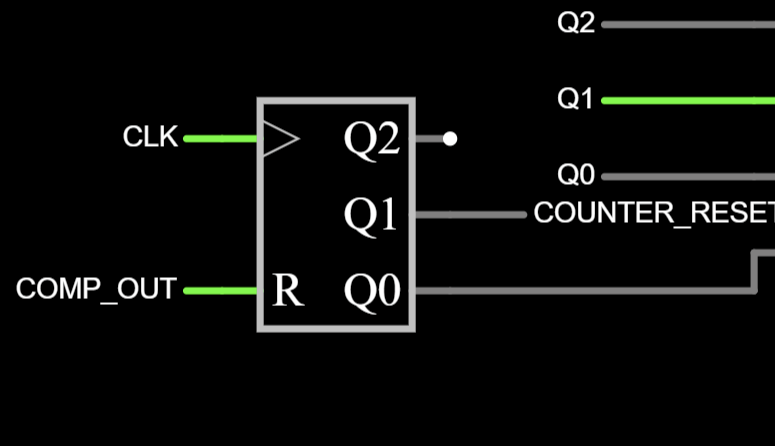

This is a binary counter. Comp out resets it, on the next clock it resets the counter.

## Task 3: ADC & DAC Quality assessment

Which ranges exist for the output?

    The output range is pm10 V

What is the DAC resolution for outputting signals?
    
    There are 2 16 bit DAC-s


In [31]:
import nidaqmx
import time

import numpy as np
import numpy.typing
from typing import Tuple

import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, ProductCategory
from nidaqmx.constants import TerminalConfiguration

Code adapted from https://github.com/ni/nidaqmx-python/blob/master/examples/synchronization/multi_function/ai_ao_sync.py

In [44]:



def get_terminal_name_with_dev_prefix(task: nidaqmx.Task, terminal_name: str) -> str:
    """Gets the terminal name with the device prefix.

    Args:
        task: Specifies the task to get the device name from.
        terminal_name: Specifies the terminal name to get.

    Returns:
        Indicates the terminal name with the device prefix.
    """
    for device in task.devices:
        if device.product_category not in [
            ProductCategory.C_SERIES_MODULE,
            ProductCategory.SCXI_MODULE,
        ]:
            return f"/{device.name}/{terminal_name}"

    raise RuntimeError("Suitable device not found in task.")

total_read = 0
number_of_samples = 1000
read = []

with nidaqmx.Task() as ai_task, nidaqmx.Task() as ao_task:

    def callback(task_handle, every_n_samples_event_type, number_of_samples, callback_data):
        """Callback function for reading signals."""
        global total_read
        global read
        read += ai_task.read(number_of_samples_per_channel=number_of_samples)
        total_read += len(read)
        print(f"Acquired data: {len(read)} samples. Total {total_read}.", end="\r")

        return 0

    ai_task.ai_channels.add_ai_voltage_chan("Dev2/ai0", terminal_config=TerminalConfiguration.RSE, min_val=-0.2, max_val=0.2)
    ai_task.timing.cfg_samp_clk_timing(1000.0, sample_mode=AcquisitionType.CONTINUOUS)
    ai_task.register_every_n_samples_acquired_into_buffer_event(1000, callback)
    terminal_name = get_terminal_name_with_dev_prefix(ai_task, "ai/StartTrigger")

    ao_task.ao_channels.add_ao_voltage_chan("Dev2/ao0")
    ao_task.timing.cfg_samp_clk_timing(1000.0, sample_mode=AcquisitionType.CONTINUOUS)
    ao_task.triggers.start_trigger.cfg_dig_edge_start_trig(terminal_name)

    actual_sampling_rate = ao_task.timing.samp_clk_rate
    print(f"Actual sampling rate: {actual_sampling_rate:g} S/s")

    frequency=1.0,
    amplitude=1e-3,
    sampling_rate=actual_sampling_rate
    number_of_samples=number_of_samples
    phase_in = 0.
    duration_time = number_of_samples / sampling_rate
    duration_radians = duration_time * 2 * np.pi
    t = np.linspace(phase_in, phase_in + duration_radians, number_of_samples, endpoint=False)
    ao_data = amplitude * np.sin(frequency * t)

    ao_task.write(ao_data)
    ao_task.start()
    ai_task.start()

    input("Acquiring samples continuously. Press Enter to stop.\n")

    ai_task.stop()
    ao_task.stop()
    
    print(f"\nAcquired {total_read} total samples.")
    print(len(read))

    



Actual sampling rate: 1000 S/s
Acquired data: 2000 samples. Total 3000.
Acquired 3000 total samples.
2000


In [56]:
.2/2**16

3.0517578125e-06

Text(0.5, 0, 'sample no')

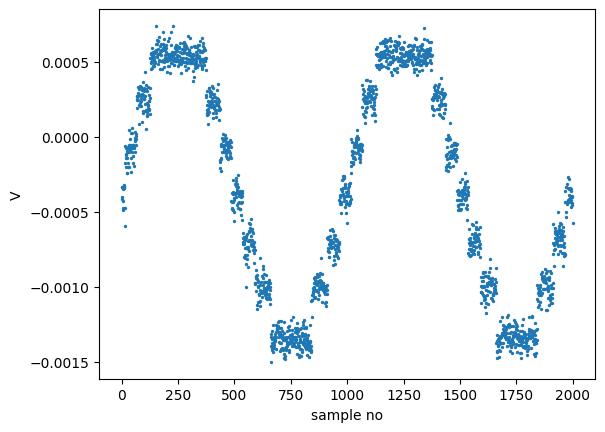

In [46]:

plt.scatter(np.linspace(0, len(read[1:]), len(read[1:])), read[1:],2)
plt.ylabel('V')
plt.xlabel("sample no")

## saved graph

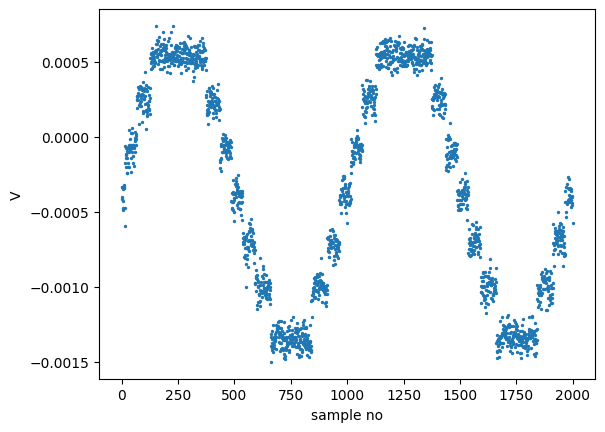

## Questions
Read from the graph (or use other LabVIEW tools if pro user) to estimate DAC:

LSB: Looks like the smallest division is around 0.1 mV




In [57]:
offset_error = np.mean(np.array(read[:len(ao_data)]) - ao_data)
print(offset_error)

-0.00034856304621127166


offset error: is around -0.3 mV


In [60]:
gain_error = (np.max(read) - np.min(read))/(2*amplitude[0])
gain_error

np.float64(1.1203654093108755)

Gain caalculation here is a tad sus.. I'm calgulatiing by the noise. For division there is a phase shift as well as a devide by zer error. But take this is a handy wavy estimate. Probably better way to do some binning or something. 